# AGHRI ZED RGB-Livox Fusion Results Summary

This notebook summarises the selected AGHRI camera-LiDAR fusion figures and tables using the frozen offline evaluator outputs. The focus is intentionally narrow: detector checkpoint comparison, fusion reliability, depth robustness, training context, and one reproducible qualitative LiDAR-association example.

The figures shown here are the selected saved figures from `results/aghri_fusion_paper_assets/selected_notebook_assets`. They are linked relative to this notebook so they display when Jupyter is opened from the `notebooks/` folder.


## Methods Compared

The fusion framework is the same in both rows below. The comparison changes the 2D person detector checkpoint and keeps the camera-guided LiDAR association/evaluation path fixed.

| Method name in figures | Detector checkpoint | Fusion method | Explanation |
|---|---|---|---|
| `Generic YOLO11s` | Public YOLO11s checkpoint | Legacy camera-guided LiDAR box association | Baseline detector used without AGHRI-specific fine-tuning. |
| `AGHRI fine-tuned` | YOLO11s fine-tuned on AGHRI ZED RGB data | Same LiDAR association and evaluator | Detector adapted to the AGHRI viewpoint, outdoor/polytunnel scenes, person scale, and clothing/occlusion patterns. |

The important control is that the LiDAR association logic is not changed between these two detector rows. This keeps the comparison focused on whether better 2D detections improve downstream fused 3D person localization.


## Metrics Used

The numerical metrics come from the offline fusion evaluator, not from RViz playback screenshots.

| metric | definition | unit |
| --- | --- | --- |
| valid fusion rate | matched valid fused detections divided by detector person detections | ratio |
| mean/median/P95 3D error | Euclidean error between fused person centre and GT 3D person centre | metres |
| error > 1m | fraction of matched valid fused detections with 3D error above 1 metre | ratio |
| FPS | approximate offline detector + fusion throughput reported by evaluator | frames/s |
| camera depth error | absolute difference along the camera optical depth axis | metres |


## Test Data Used

The frozen held-out benchmark uses all six official AGHRI test recordings.

| Dataset part | Test recording | Scenario | Robot motion |
|---|---|---|---|
| `dataset_part1` | `footpath1_p1_nj+mk+gl_1walk+check_mv_11_12_2024_1_label` | Footpath | Moving |
| `dataset_part1` | `footpath1_p1_oj+mk+gl_1walk+check_st_11_12_2024_1_label` | Footpath | Stationary |
| `dataset_part3` | `in_straw_3pick_diff_st_10_24_2024_5_a_label` | Polytunnel | Stationary |
| `dataset_part3` | `out_straw_1push_1walk_1swap_st_11_07_2024_1_b_label` | Polytunnel/outdoor straw | Stationary |
| `dataset_part4` | `out_vine_1push_3carry_st_ly_11_06_2024_1_label` | Vineyard | Stationary |
| `dataset_part4` | `out_vine_4swap+walk_st_ly_11_06_2024_2_label` | Vineyard | Stationary |

The overall result table and the F1/F2/F3 summary use all six recordings. The representative-scenario figure uses one selected bag per scenario only, so that figure is easier to read and should not be confused with the full six-recording aggregate.


## Main Results Table

| model | detections | matched | valid_rate | mean_m | median_m | p95_m | err_gt_1m | fps |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Generic YOLO11s | 2787 | 2561 | 0.9218 | 0.4765 | 0.2038 | 1.8703 | 0.0859 | 69.53 |
| AGHRI fine-tuned | 2534 | 2433 | 0.9680 | 0.3926 | 0.1911 | 1.3595 | 0.0748 | 69.19 |

**Key observation.** The AGHRI fine-tuned detector improves the fusion output even though the LiDAR association method is kept fixed. Compared with generic YOLO11s, mean 3D error drops from 0.4765 m to 0.3926 m, P95 error drops from 1.8703 m to 1.3595 m, and valid fusion rate increases from 0.9218 to 0.9680. Runtime remains essentially unchanged.


In [ ]:
# Optional reproducibility cell: show where the selected assets live.
from pathlib import Path

ASSETS = Path("/home/prabuddhi/Desktop/Early_Fus/results/aghri_fusion_paper_assets/selected_notebook_assets")
print(ASSETS)
print("selected asset files:", len(list(ASSETS.rglob("*"))))


## Figure 1: Fusion Method Overview

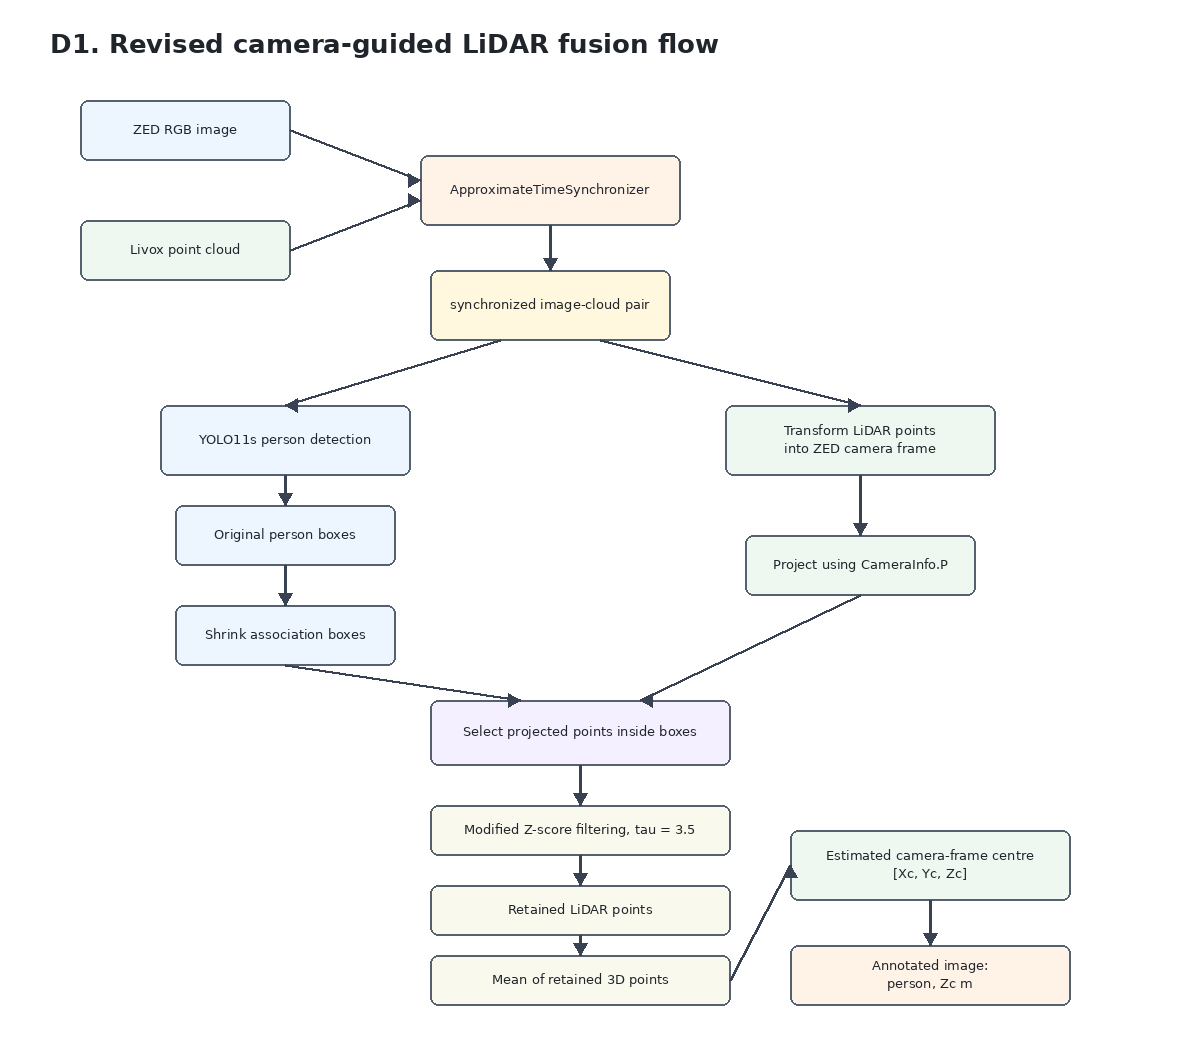

The runtime first synchronizes the ZED RGB image and Livox point cloud with an approximate-time synchronizer. YOLO11s produces person boxes on the synchronized image. In parallel, the point cloud is transformed into the ZED camera frame and projected into image coordinates using `CameraInfo.P`. The projected points inside the shrunken person association boxes become candidates. Modified Z-score filtering with `tau = 3.5` removes outliers, and the retained 3D points are averaged to estimate the camera-frame person centre `[Xc, Yc, Zc]`. The displayed distance label is the camera-frame depth component `Zc`.


## Figure 2: Overall Frozen-Test Summary

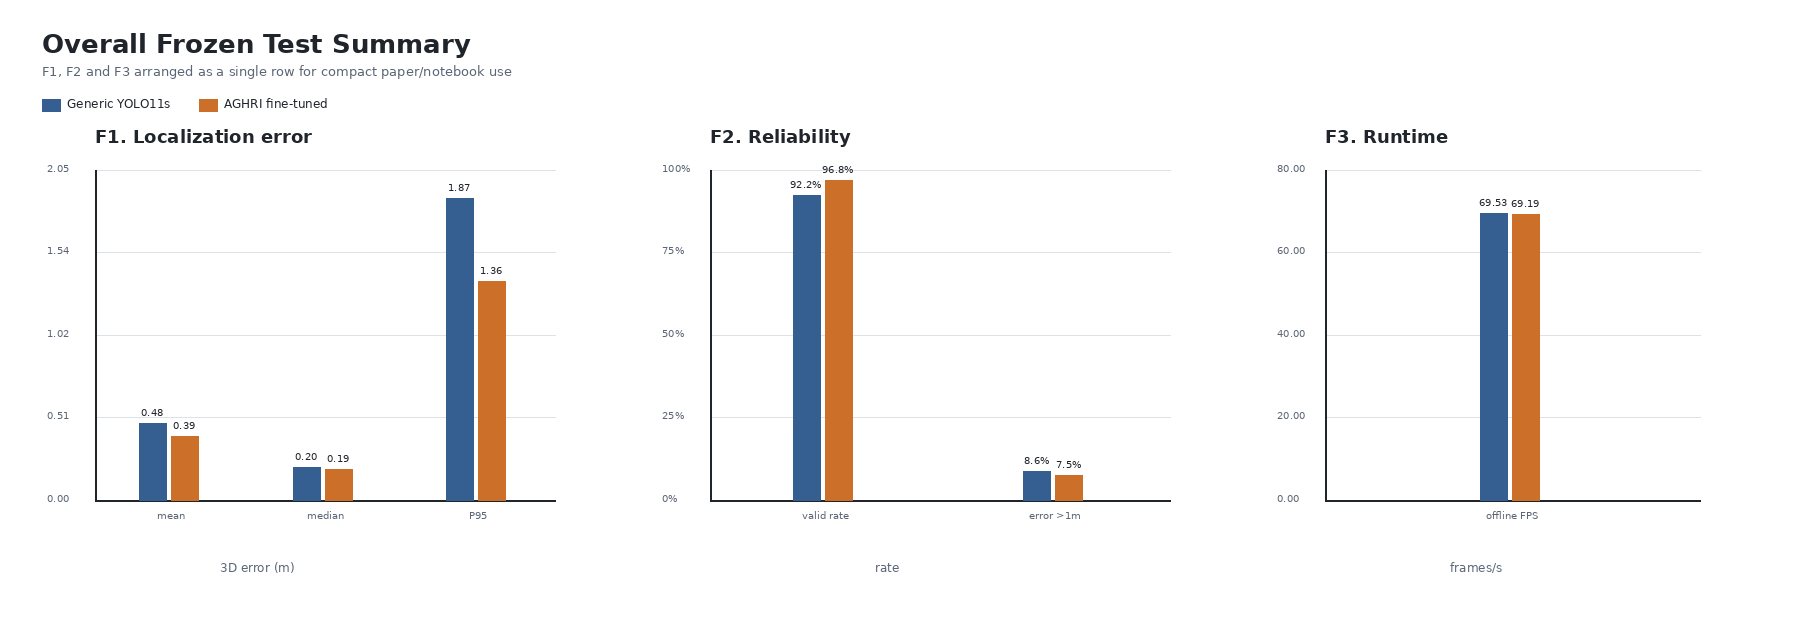

This combined figure places the three core summaries in one row. `F1_overall_localization_errors` shows that the fine-tuned detector reduces mean, median, and P95 3D localization error. `F2_reliability` shows a higher valid fusion rate and a lower fraction of errors above 1 m. `F3_runtime` shows that both checkpoints run at similar offline throughput, so the accuracy improvement is not bought by a meaningful runtime penalty.


## Figure 3: Representative Scenario Mean Error

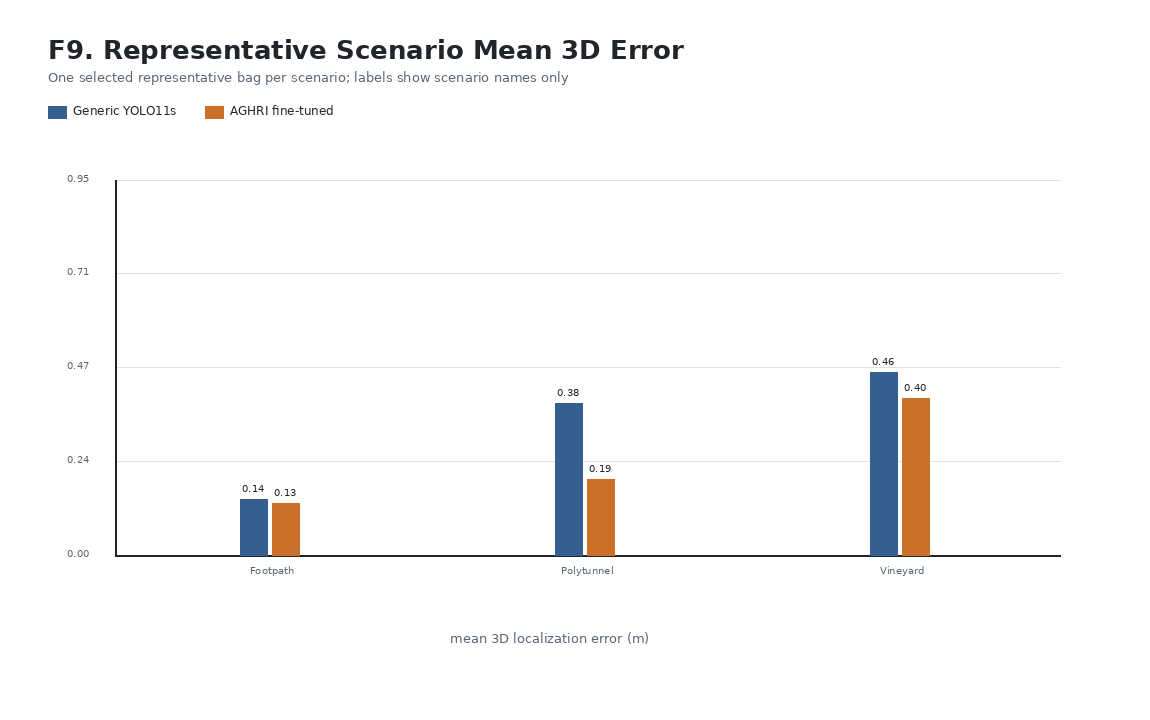

This figure is a compact scenario-level view. It uses one selected representative bag per scenario rather than all six test bags:

| Scenario | Selected bag used in this figure |
|---|---|
| Footpath | `dataset_part1/footpath1_p1_oj+mk+gl_1walk+check_st_11_12_2024_1_label` |
| Polytunnel | `dataset_part3/in_straw_3pick_diff_st_10_24_2024_5_a_label` |
| Vineyard | `dataset_part4/out_vine_4swap+walk_st_ly_11_06_2024_2_label` |

The x-axis intentionally uses only the scenario names. The trend is consistent with the full aggregate: the AGHRI fine-tuned detector gives lower mean 3D error in the selected representative bags.


## Figure 4: Depth Robustness

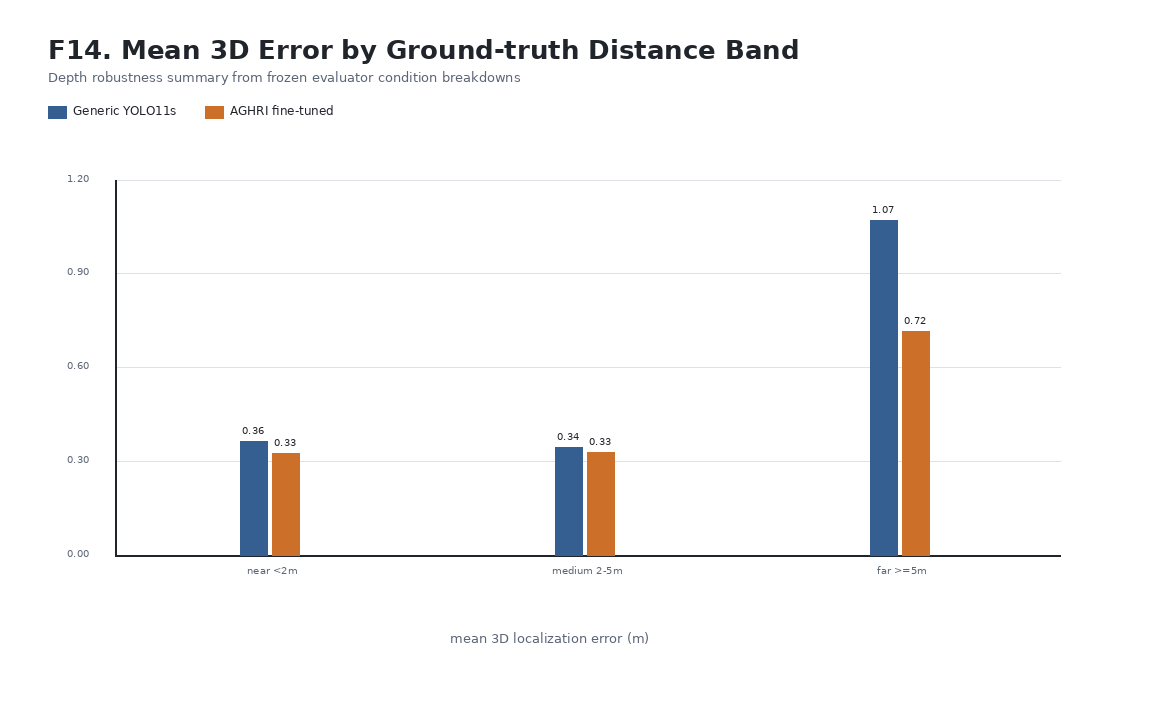

`F14_depth_bins` reports mean 3D error by ground-truth distance band. This is useful because camera-LiDAR fusion can behave differently at near, medium, and far ranges: nearby people may occupy large image regions, while far people have fewer retained LiDAR points and smaller projected boxes. The fine-tuned detector reduces the mean error especially in the farther range, which is where detector quality and point selection become more fragile.


## Figure 5: YOLO11s Fine-tuning Curves

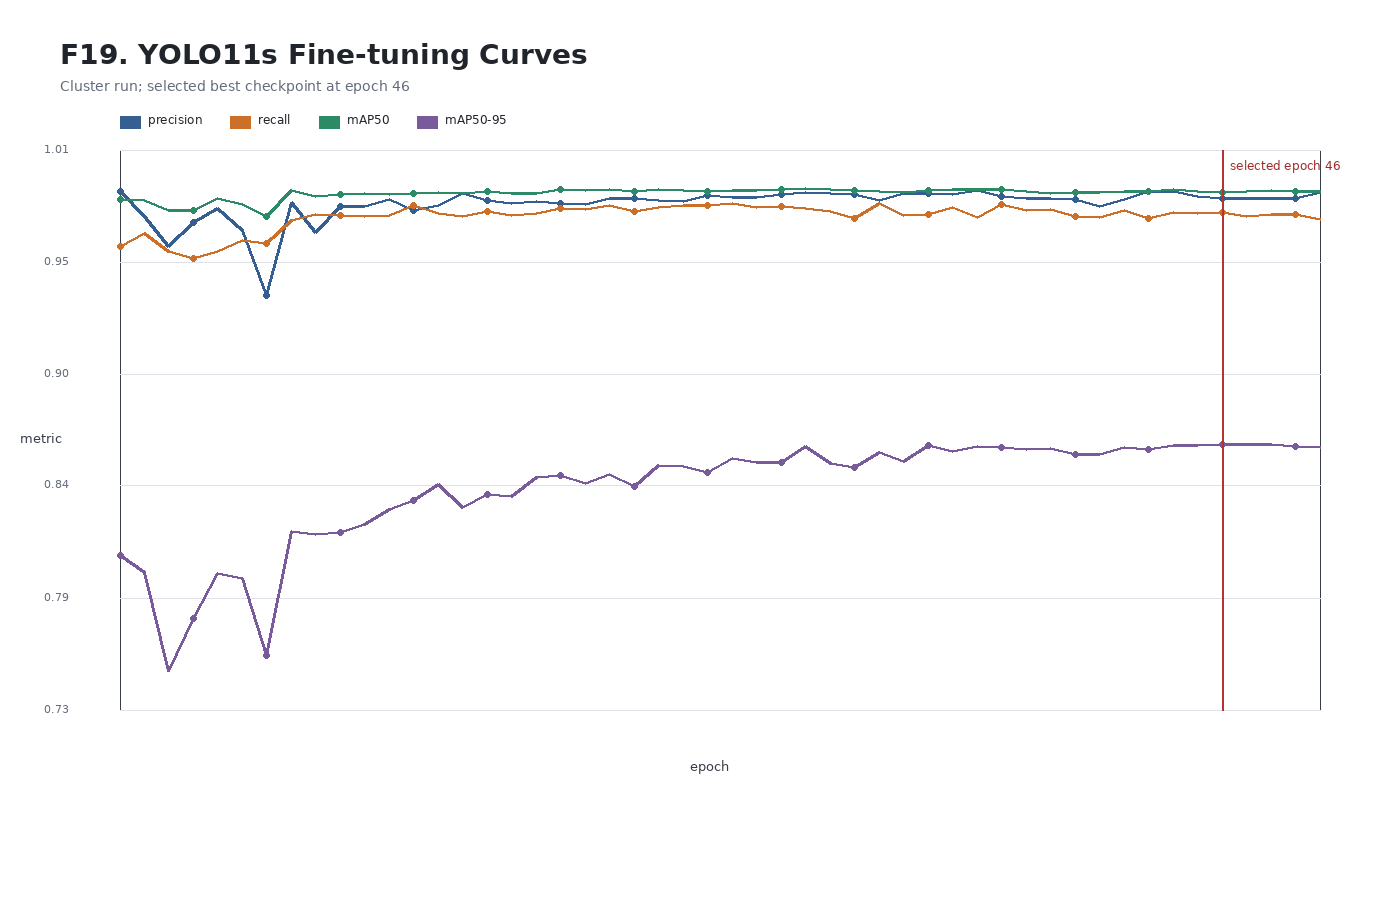

`F19_training_curves` shows the cluster fine-tuning run used to adapt YOLO11s to AGHRI ZED RGB images. The curves track validation precision, recall, mAP50, and mAP50-95 over training epochs. Epoch 46 is marked as the selected best checkpoint. That checkpoint is then used in the frozen fusion comparison, so the downstream results measure how an AGHRI-adapted 2D detector changes the final fused 3D person localization.


## Figure 6: Step-by-step LiDAR Association Example

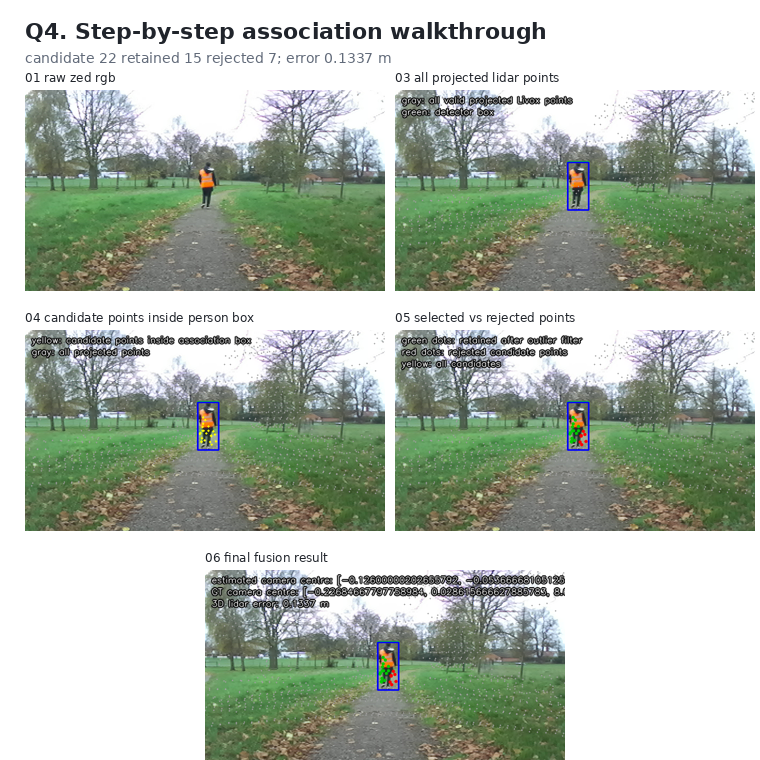

`Q4_step_by_step_association` is a self-contained qualitative walkthrough. The raw ZED image first shows the target person. The projected-point panel then shows all LiDAR points that land inside the image. The candidate panel isolates the points inside the shrunken person association box. The selected-vs-rejected panel shows the modified Z-score filter in action: 22 candidate points enter the filter, 15 are retained, and 7 are rejected. The final panel averages the retained 3D points and recomputes a LiDAR-centre error of about 0.1337 m. This example is included because every step can be reproduced from `/home/prabuddhi/Desktop/aghri_fusion_real_example`.


## ROS Topics and Frames

| topic | type | frame |
| --- | --- | --- |
| /dataset/cam_zed_rgb/image | sensor_msgs/Image | front_left_camera_optical_frame |
| /dataset/lidar/points | sensor_msgs/PointCloud2 | front_lidar_link |
| /dataset/cam_zed_rgb/camera_info | sensor_msgs/CameraInfo | front_left_camera_optical_frame |
| /dataset/cam_fish_front/camera_info | sensor_msgs/CameraInfo | fish_front_camera_link_optical |
| /dataset/cam_fish_left/camera_info | sensor_msgs/CameraInfo | fish_left_camera_link_optical |
| /dataset/cam_fish_right/camera_info | sensor_msgs/CameraInfo | fish_right_camera_link_optical |
| /tf | tf2_msgs/TFMessage | map -> base_link |
| /tf_static | tf2_msgs/TFMessage | static sensor tree |

The all-topic ROS 2 bags contain the ZED RGB image and CameraInfo, three fisheye CameraInfo streams, Livox point clouds, `/tf`, and `/tf_static`. The fusion node only needs the ZED RGB stream, ZED CameraInfo, Livox cloud, and TF chain for the published ZED RGB-Livox result; the extra topics remain in the bag for completeness and reproducibility.


## Figure 7: ROS Playback Qualitative Example

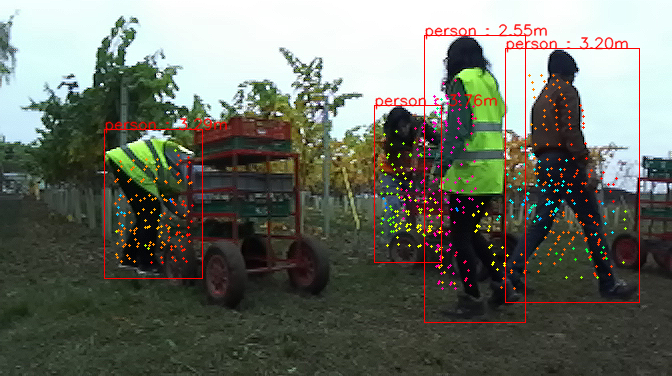

This image was captured directly from the ROS 2 playback output topic `/camera_lidar_fusion/result` while playing `dataset_part4/out_vine_4swap+walk_st_ly_11_06_2024_2_label`. It shows the fine-tuned YOLO11s detections, projected Livox points over the ZED RGB image, and the displayed person depth labels. The numeric label is the camera-frame depth `Zc` of the fused person centre, so it should be read as forward depth from the ZED camera rather than full Euclidean range.


## Summary

Across the frozen AGHRI fusion benchmark, AGHRI fine-tuning improves the detector input to the same LiDAR association pipeline. The main quantitative effect is lower 3D localization error and higher valid fusion rate, with similar runtime. The representative scenario view gives a simpler environment-level reading, the depth-bin figure checks range sensitivity, and the step-by-step qualitative example explains how projected LiDAR points become the final camera-frame centre shown on the annotated image.
